<a href="https://colab.research.google.com/github/lakhbir-05/CodeAlpha_Disease-prediction-/blob/main/Diseaseprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#heart disease





In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d johnsmith88/heart-disease-dataset
!unzip -q heart-disease-dataset.zip -d heart_disease

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
100% 6.18k/6.18k [00:00<00:00, 14.9MB/s]



In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
import glob

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
target


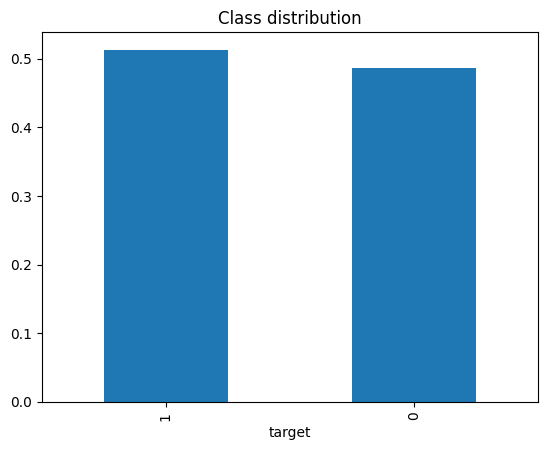

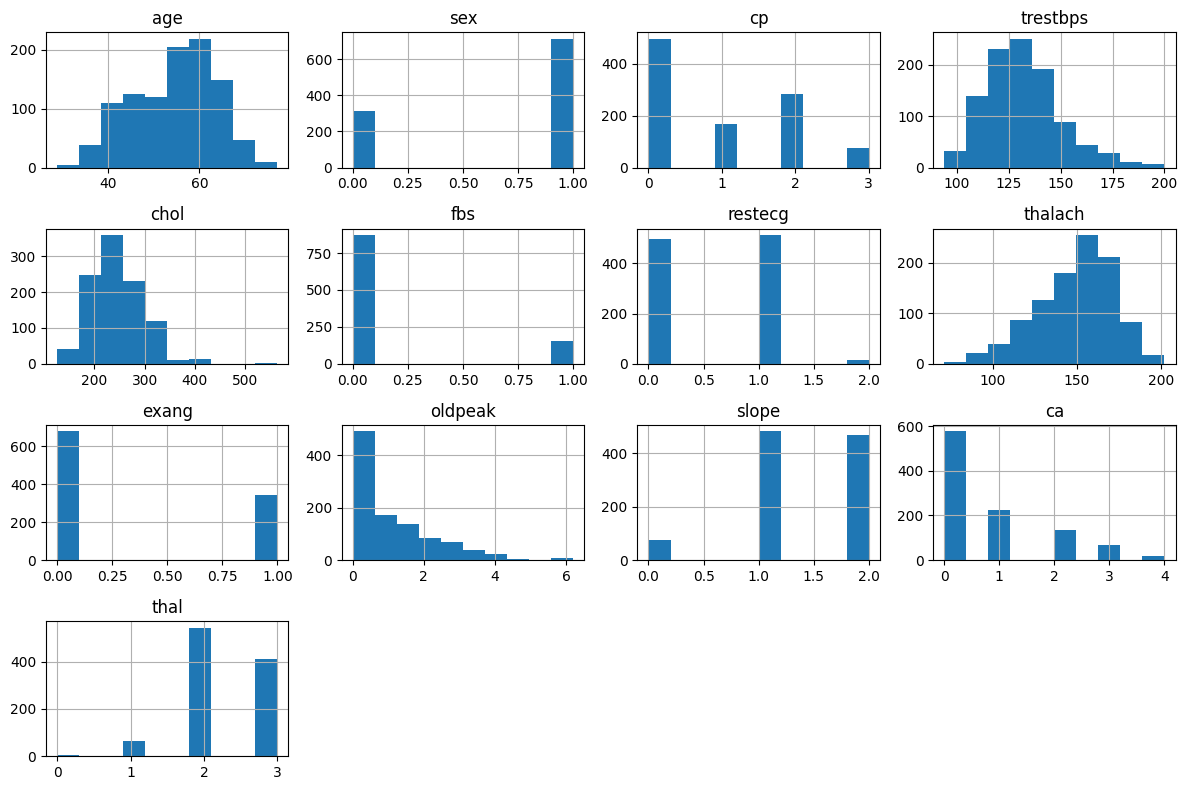

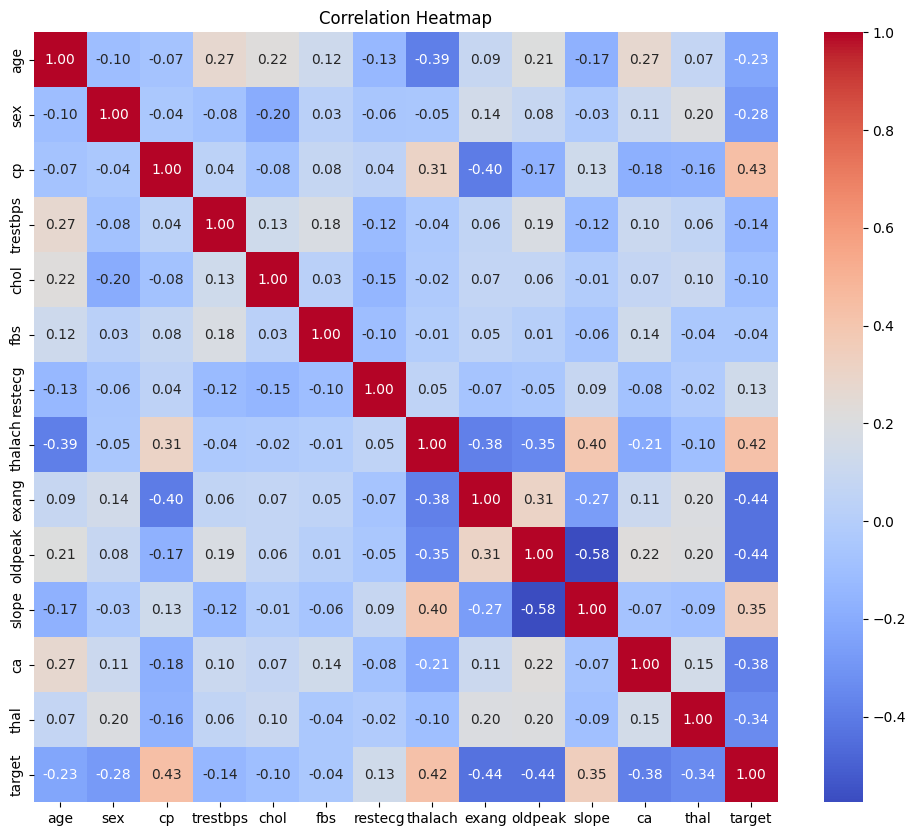

Correlation with target:
 hr_age_ratio     0.362491
oldpeak_slope   -0.297704
target           1.000000
Name: target, dtype: float64

Target rate by age group:
 age_group
<40      0.661765
40-50    0.646119
55+      0.381503
Name: target, dtype: float64

Target rate by oldpeak group:
 oldpeak_group
low       0.721591
medium    0.544693
high      0.244444
Name: target, dtype: float64
Columns not needed dropped


/tmp/ipykernel_5318/3694801018.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_check = df.groupby('age_group')['target'].mean()
/tmp/ipykernel_5318/3694801018.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oldpeak_check = df.groupby('oldpeak_group')['target'].mean()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,oldpeak_group
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,40-50,medium
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,40-50,high
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,55+,high
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,55+,low
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,55+,high


In [ ]:
import glob

csv_files = glob.glob('/content/heart_disease/*.csv')
if csv_files:
    df = pd.read_csv(csv_files[0])
else:
    raise FileNotFoundError("No CSV file found in /content/heart_disease/")

display(df.head())
print(df.shape)

df.info()

df.describe(include='all').T

df.isnull().sum()

TARGET_COL = 'target'
df[TARGET_COL].value_counts()
df[TARGET_COL].value_counts(normalize=True)
print(TARGET_COL)


df[TARGET_COL].value_counts(normalize=True).plot(kind='bar')
plt.title('Class distribution')
plt.show()

df.drop(columns=[TARGET_COL]).hist(figsize=(12, 8))
plt.tight_layout(); plt.show()

import seaborn as sns

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

df_backup = df.copy()

df.head()

df_backup.head()

df['hr_age_ratio'] = df['thalach'] / (220 - df['age'])
df['oldpeak_slope'] = df['oldpeak'] * df['slope']
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 55, 100], labels=['<40','40-50', '55+'])
df["oldpeak_group"] = pd.qcut(df["oldpeak"], q=3, labels=["low", "medium", "high"], duplicates='drop')

continuous_check = df[['hr_age_ratio', 'oldpeak_slope', 'target']].corr()['target']
print("Correlation with target:\n", continuous_check)

age_group_check = df.groupby('age_group')['target'].mean()
print("\nTarget rate by age group:\n", age_group_check)

oldpeak_check = df.groupby('oldpeak_group')['target'].mean()
print("\nTarget rate by oldpeak group:\n", oldpeak_check)

df[['thalach', 'age', 'target']].corr()['target']

df[['oldpeak', 'slope', 'target']].corr()['target']

df.head()

df = df.drop(columns=['hr_age_ratio'])
df = df.drop(columns=['oldpeak_slope'])
print("Columns not needed dropped")

df.head()

target column removed
Pipelines preprocessed
Data split complete
(820, 36)
(205, 36)
(656, 36)
(164, 36)
Models imported
Logistic Regression C=0.01: validation accuracy = 0.8415
Logistic Regression C=0.1: validation accuracy = 0.8598
Logistic Regression C=1: validation accuracy = 0.8598
Logistic Regression C=10: validation accuracy = 0.8720

Best C: 10, Validation Accuracy: 0.8720
Decision Tree max_depth=3: validation accuracy = 0.8293
Decision Tree max_depth=5: validation accuracy = 0.8780
Decision Tree max_depth=10: validation accuracy = 0.9695
Decision Tree max_depth=None: validation accuracy = 0.9695
Best max_depth: 10, Validation Accuracy: 0.9695

Random Forest n_estimators=100, max_depth=5: validation accuracy = 0.8963
Random Forest n_estimators=100, max_depth=10: validation accuracy = 0.9939
Random Forest n_estimators=100, max_depth=None: validation accuracy = 0.9939
Random Forest n_estimators=200, max_depth=5: validation accuracy = 0.9085
Random Forest n_estimators=200, max_dep

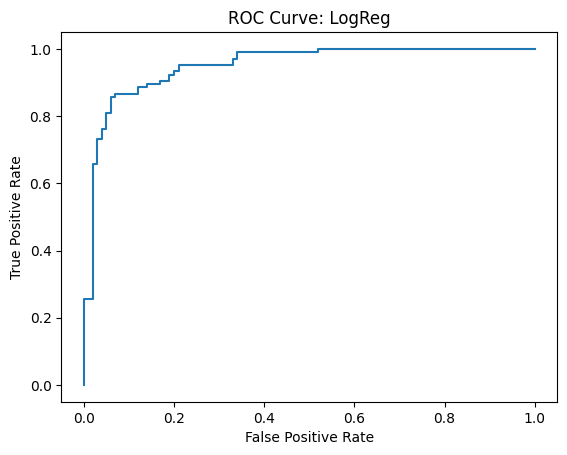

=== DecisionTree ===
Accuracy : 0.9853658536585366
Precision: 1.0
Recall   : 0.9714285714285714
F1       : 0.9855072463768116
Confusion matrix: [[100   0]
 [  3 102]]
ROC-AUC  : 0.9857142857142858


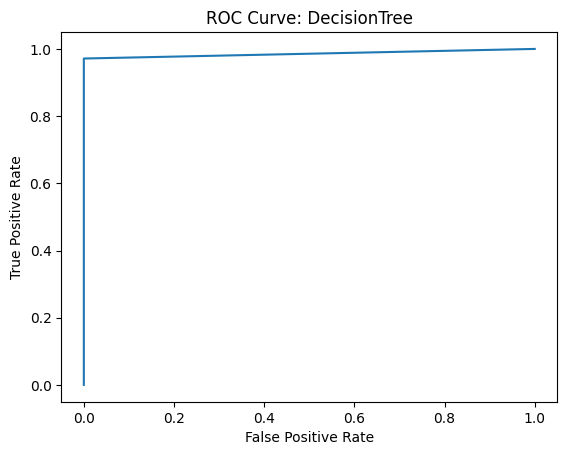

=== RandomForest ===
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1       : 1.0
Confusion matrix: [[100   0]
 [  0 105]]
ROC-AUC  : 1.0


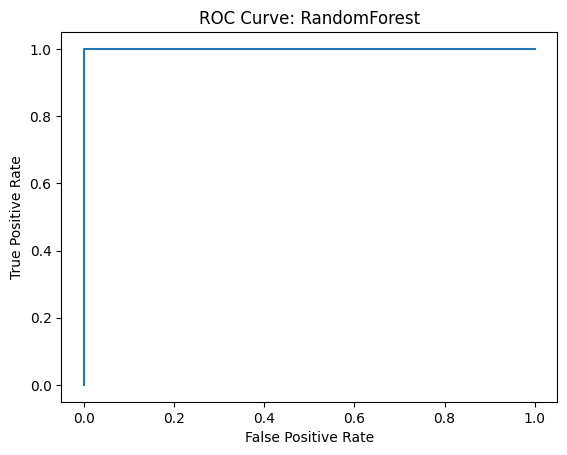

In [ ]:
# TODO: Split features/target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("target column removed")
X.head()

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'age_group', 'oldpeak_group']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
print("Pipelines preprocessed")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size = 0.2, random_state = RANDOM_STATE, stratify=y_train
)

print("Data split complete")

X_train_prepared = preprocess.fit_transform(X_train)
X_test_prepared = preprocess.transform(X_test)

print(X_train_prepared.shape)
print(X_test_prepared.shape)

X_train_sub_prepared = preprocess.fit_transform(X_train_sub)
X_val_prepared = preprocess.transform(X_val)

print(X_train_sub_prepared.shape)
print(X_val_prepared.shape)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    'LogReg': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),

}
print("Models imported")

best_log_reg_score = 0
best_log_reg_C = None

for C in [0.01, 0.1, 1, 10]:
    log_reg_candidate = LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE)
    log_reg_candidate.fit(X_train_sub_prepared, y_train_sub)
    val_acc = log_reg_candidate.score(X_val_prepared, y_val)
    print(f"Logistic Regression C={C}: validation accuracy = {val_acc:.4f}")
    if val_acc > best_log_reg_score:
        best_log_reg_score = val_acc
        best_log_reg_C = C

print(f"\nBest C: {best_log_reg_C}, Validation Accuracy: {best_log_reg_score:.4f}")

best_log_reg = LogisticRegression(C=best_log_reg_C, max_iter=1000, random_state=RANDOM_STATE)
best_log_reg.fit(X_train_prepared, y_train)

best_tree_score = 0
best_tree_depth = None

for depth in [3, 5, 10, None]:
    tree_candidate = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    tree_candidate.fit(X_train_sub_prepared, y_train_sub)
    val_acc = tree_candidate.score(X_val_prepared, y_val)
    print(f"Decision Tree max_depth={depth}: validation accuracy = {val_acc:.4f}")
    if val_acc > best_tree_score:
        best_tree_score = val_acc
        best_tree_depth = depth

print(f"Best max_depth: {best_tree_depth}, Validation Accuracy: {best_tree_score:.4f}\n")

best_tree = DecisionTreeClassifier(max_depth=best_tree_depth, random_state=RANDOM_STATE)
best_tree.fit(X_train_prepared, y_train)


best_rf_score = 0
best_rf_params = None

for n_estimators in [100, 200]:
    for depth in [5, 10, None]:
        rf_candidate = RandomForestClassifier(
            n_estimators = n_estimators, max_depth = depth, random_state = RANDOM_STATE
        )
        rf_candidate.fit(X_train_sub_prepared, y_train_sub)
        val_acc = rf_candidate.score(X_val_prepared, y_val)
        print(f"Random Forest n_estimators={n_estimators}, max_depth={depth}: validation accuracy = {val_acc:.4f}")
        if val_acc > best_rf_score:
            best_rf_score = val_acc
            best_rf_params = {"n_estimators": n_estimators, "max_depth": depth}

print(f"Best params: {best_rf_params}, Validation Accuracy: {best_rf_score:.4f}\n")

best_rf = RandomForestClassifier(**best_rf_params, random_state=RANDOM_STATE)
best_rf.fit(X_train_prepared, y_train)



print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")



from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve

def evaluate_classifier(name, clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    print(f'=== {name} ===')
    print('Accuracy :', accuracy_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred, average='binary', zero_division=0))
    print('Recall   :', recall_score(y_test, y_pred, average='binary', zero_division=0))
    print('F1       :', f1_score(y_test, y_pred, average='binary', zero_division=0))
    print('Confusion matrix:', confusion_matrix(y_test, y_pred))

    # ROC-AUC (binary) if possible
    if hasattr(clf, 'predict_proba'):
        y_proba = clf.predict_proba(X_test)[:, 1]
        print('ROC-AUC  :', roc_auc_score(y_test, y_proba))
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve: {name}')
        plt.show()


models = {
    'LogReg': LogisticRegression(C=best_log_reg_C, max_iter=2000, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(max_depth=best_tree_depth, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(**best_rf_params, random_state=RANDOM_STATE),
}


for name, model in models.items():
    clf = Pipeline(steps=[('preprocess', preprocess), ('model', model)])
    clf.fit(X_train, y_train)
    evaluate_classifier(name, clf, X_test, y_test)






In [ ]:
best_heart_model = GradientBoostingClassifier(
    n_estimators=586,
    learning_rate=0.09474542075886146,
    max_depth=6,
    min_samples_split=18,
    min_samples_leaf=2,
    random_state=42
)

best_heart_model.fit(X_train_prepared, y_train)

GradientBoostingClassifier(learning_rate=0.09474542075886146, max_depth=6,
                           min_samples_leaf=2, min_samples_split=18,
                           n_estimators=586, random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
import joblib

heart_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', best_rf)   # or your best GradientBoosting model
])

heart_pipeline.fit(X_train, y_train)

joblib.dump(heart_pipeline, "heart_model.pkl")

['heart_model.pkl']

In [ ]:
joblib.dump(best_heart_model, "heart_model.pkl")

['heart_model.pkl']

In [ ]:
print(type(heart_model))
print(hasattr(heart_model, "estimators_"))

<class 'sklearn.pipeline.Pipeline'>
False


# diabetes dataset

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.0 MB/s eta 0:00:00


In [ ]:
!kaggle datasets download -d uciml/pima-indians-diabetes-database
!unzip -q pima-indians-diabetes-database.zip -d diabetes

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
100% 8.91k/8.91k [00:00<00:00, 24.5MB/s]



10 FOLD CV RESULTS :
____________________________________________________________________________________________
LogisticRegression	:	 0.7760423786739576
DecisionTreeClassifier	:	 0.8476418318523582
SVM_Linear		:	 0.7773752563226248
SVM_RBF			:	 0.8450615174299385
K_NEAREST_NEIGHBOR	:	 0.7956937799043062
XGBoostCLASSIFIER	:	 0.8802973342447027
Gradient_Boosting	:	 0.881596035543404
RandomForestClassifier	:	 0.8789644565960355


/tmp/ipykernel_5318/3460975854.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df, ax=ax, palette='coolwarm')


--- Tuned Metrics DataFrame ---
                    Model Name  10 fold cv result  \
0               XGB Classifier           0.894600   
1  Gradient Boosting Regressor           0.901042   
2     Random Forest classifier           0.894583   

                                     Best Parameters  
0  {'n_estimators': 393, 'learning_rate': 0.07178...  
1  {'n_estimators': 382, 'learning_rate': 0.01293...  
2  {'n_estimators': 136, 'max_depth': 17, 'min_sa...  


/tmp/ipykernel_5318/3460975854.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


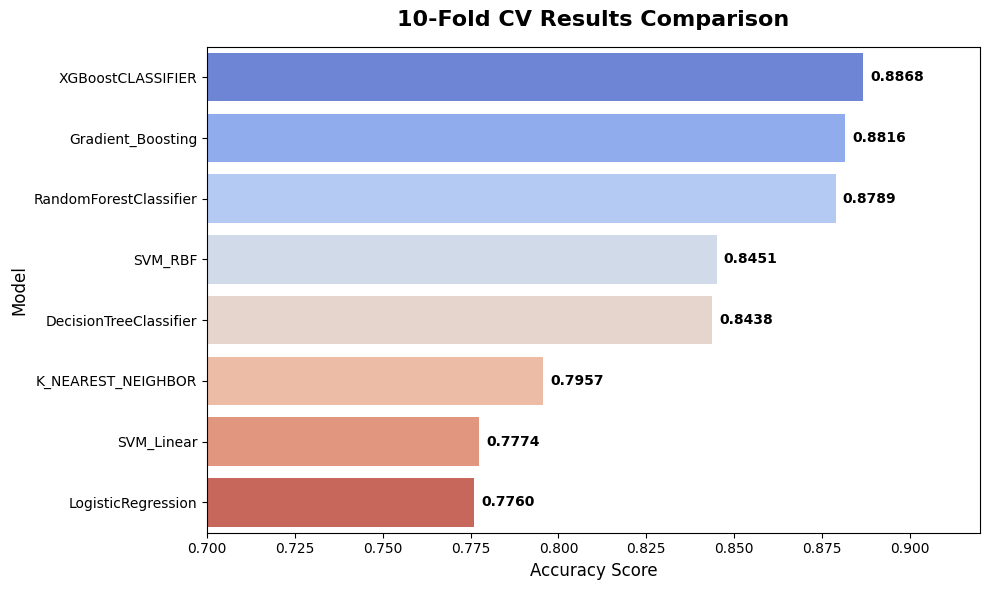

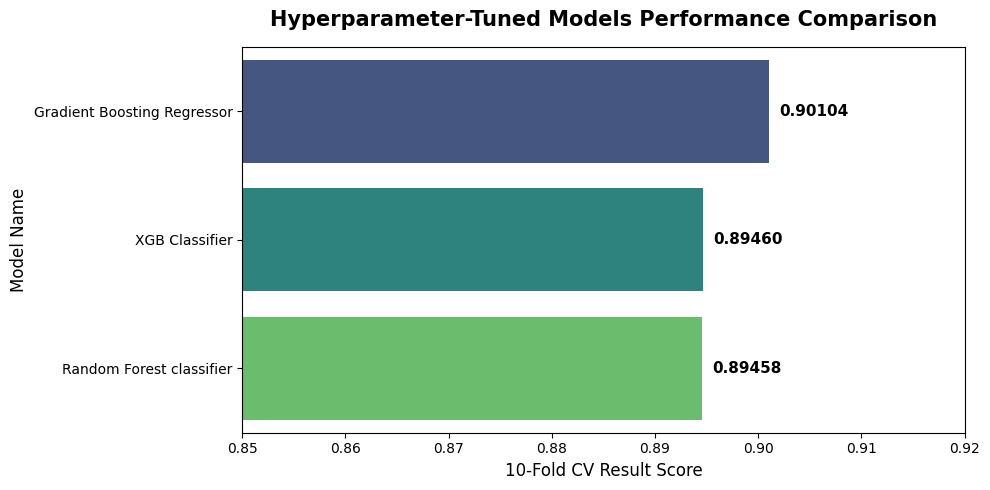

In [ ]:
import glob

data = pd.read_csv('/content/diabetes/diabetes.csv')


data.isna().sum()

data.describe()

#IMPUTATIONS AS THESE VALUES CANNOT BE ZEROS

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols_with_zeros] = data[cols_with_zeros].replace(0, np.nan)

for col in cols_with_zeros:
    data[col] = data.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

data.describe()

data.corr()

X = data.iloc[:,0:-1]
y = data.iloc[:,-1]

ss = StandardScaler()
X = ss.fit_transform(X)

X = pd.DataFrame(X)


lr = LogisticRegression()
tree = DecisionTreeClassifier()
svm1 = SVC(kernel = 'linear',probability=True)
svm2 = SVC(kernel = 'rbf',probability=True)
KNN = KNeighborsClassifier(n_neighbors = 45)
xgb = XGBClassifier()
gbc = GradientBoostingClassifier()
rfc = RandomForestClassifier()


print("10 FOLD CV RESULTS :")
print("____________________________________________________________________________________________")
print("LogisticRegression\t:\t",np.mean(cross_val_score(lr , X , y , cv = 10 ,scoring='accuracy', n_jobs = -1)))
print("DecisionTreeClassifier\t:\t",np.mean(cross_val_score(tree , X , y , cv = 10 ,scoring='accuracy', n_jobs = -1)))
print("SVM_Linear\t\t:\t",np.mean(cross_val_score(svm1 , X , y , cv = 10 ,scoring='accuracy', n_jobs = -1)))
print("SVM_RBF\t\t\t:\t",np.mean(cross_val_score(svm2 , X , y , cv = 10 ,scoring='accuracy', n_jobs = -1)))
print("K_NEAREST_NEIGHBOR\t:\t",np.mean(cross_val_score(KNN , X , y , cv = 10 ,scoring='accuracy', n_jobs = -1)))
print("XGBoostCLASSIFIER\t:\t",np.mean(cross_val_score(xgb , X , y , cv = 10 ,scoring='accuracy', n_jobs = -1)))
print("Gradient_Boosting\t:\t",np.mean(cross_val_score(gbc , X , y , cv = 10 ,scoring='accuracy', n_jobs = -1)))
print("RandomForestClassifier\t:\t",np.mean(cross_val_score(rfc , X , y , cv = 10 ,scoring='accuracy', n_jobs = -1)))



import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Model': [
        'LogisticRegression', 'DecisionTreeClassifier', 'SVM_Linear', 'SVM_RBF',
        'K_NEAREST_NEIGHBOR', 'XGBoostCLASSIFIER', 'Gradient_Boosting', 'RandomForestClassifier'
    ],
    'Accuracy': [
        0.7760423786739576, 0.8437628161312372, 0.7773752563226248, 0.8450615174299385,
        0.7956937799043062, 0.8867566643882434, 0.881596035543404, 0.8789473684210527
    ]
}

df = pd.DataFrame(data)
df = df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Create a clean horizontal bar plot
sns.barplot(x='Accuracy', y='Model', data=df, ax=ax, palette='coolwarm')

# 4. Customize labels, title, and layout
ax.set_title('10-Fold CV Results Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Accuracy Score', fontsize=12)
ax.set_ylabel('Model', fontsize=12)

# Zoom in on the relevant accuracy range to clearly see performance gaps
ax.set_xlim(0.70, 0.92)

# 5. Add text labels at the end of each bar showing the exact scores
for index, row in df.iterrows():
    ax.text(
        x=row['Accuracy'] + 0.002,
        y=index,
        s=f"{row['Accuracy']:.4f}",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

# 6. Save the visualization cleanly
plt.tight_layout()
plt.savefig('cv_results_chart.png', dpi=300)

#DECENT RESULTS , BUT TUNING HYPERPARAMETERS OF TOP 3 MODELS WILL GIVE BETTER RESULT :
import optuna

#XG BOOST
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'n_jobs' : -1
    }
    model = XGBClassifier(**params, random_state=42)
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    return np.mean(scores)

# Gradient Boosting
def objective_gbr(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    return np.mean(scores)

# Random Forest
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }
    model = RandomForestClassifier(**params, n_jobs=-1, random_state=42)
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    return np.mean(scores)


data = {
    'Model Name': [
        'XGB Classifier',
        'Gradient Boosting Regressor',
        'Random Forest classifier'
    ],
    '10 fold cv result': [
        0.8946001367053998,
        0.9010423786739576,
        0.8945830485304169
    ],
    'Best Parameters': [
        {'n_estimators': 393, 'learning_rate': 0.07178888663094157, 'max_depth': 4, 'gamma': 1.8247558331717264},
        {'n_estimators': 382, 'learning_rate': 0.012930525445131411, 'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 2},
        {'n_estimators': 136, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': None}
    ]
}

Tuned_metrics = pd.DataFrame(data)





print("--- Tuned Metrics DataFrame ---")
print(Tuned_metrics)


tuned_metrics_sorted = Tuned_metrics.sort_values(by='10 fold cv result', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))

# Generate horizontal bar plot
sns.barplot(
    x='10 fold cv result',
    y='Model Name',
    data=tuned_metrics_sorted,
    ax=ax,
    palette='viridis'
)

# Customize title and axis labels
ax.set_title('Hyperparameter-Tuned Models Performance Comparison', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('10-Fold CV Result Score', fontsize=12)
ax.set_ylabel('Model Name', fontsize=12)

# Zoom in on the axis scale to highlight subtle performance variations
ax.set_xlim(0.85, 0.92)

# Annotate each bar with its exact score value rounded to 5 decimal places
for index, row in tuned_metrics_sorted.iterrows():
    ax.text(
        x=row['10 fold cv result'] + 0.001,
        y=index,
        s=f"{row['10 fold cv result']:.5f}",
        va='center',
        ha='left',
        fontsize=11,
        fontweight='bold'
    )

# Clean up layout boundary padding and save chart
plt.tight_layout()
plt.savefig('tuned_metrics_chart.png', dpi=300)






/tmp/ipykernel_5318/2483011544.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df, ax=ax, palette='coolwarm')


--- Tuned Metrics DataFrame ---
                    Model Name  10 fold cv result  \
0               XGB Classifier           0.894600   
1  Gradient Boosting Regressor           0.901042   
2     Random Forest classifier           0.894583   

                                     Best Parameters  
0  {'n_estimators': 393, 'learning_rate': 0.07178...  
1  {'n_estimators': 382, 'learning_rate': 0.01293...  
2  {'n_estimators': 136, 'max_depth': 17, 'min_sa...  


/tmp/ipykernel_5318/2483011544.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


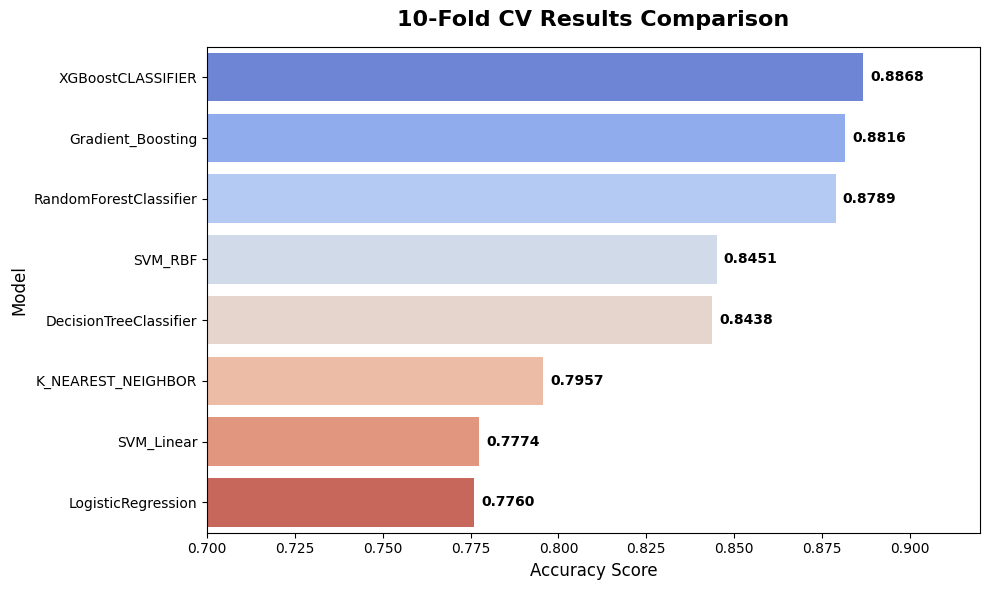

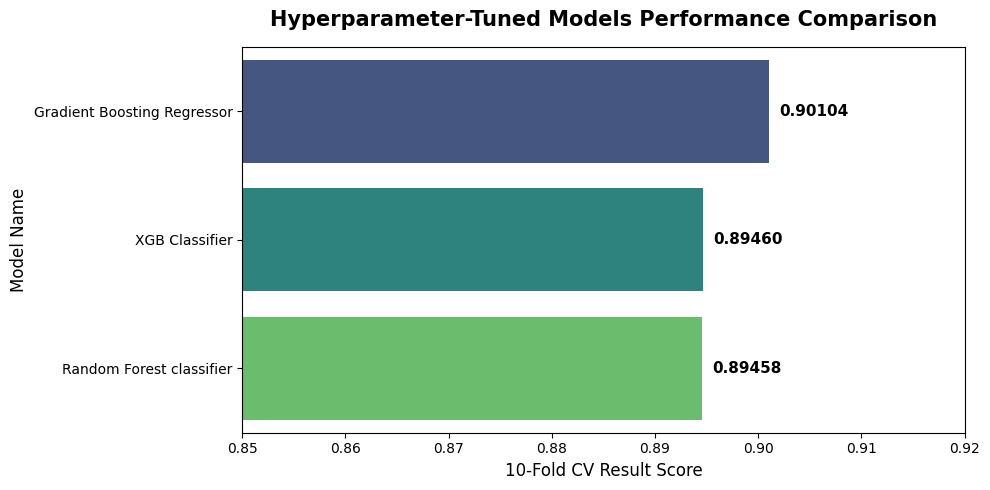

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Model': [
        'LogisticRegression', 'DecisionTreeClassifier', 'SVM_Linear', 'SVM_RBF',
        'K_NEAREST_NEIGHBOR', 'XGBoostCLASSIFIER', 'Gradient_Boosting', 'RandomForestClassifier'
    ],
    'Accuracy': [
        0.7760423786739576, 0.8437628161312372, 0.7773752563226248, 0.8450615174299385,
        0.7956937799043062, 0.8867566643882434, 0.881596035543404, 0.8789473684210527
    ]
}

df = pd.DataFrame(data)
df = df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Create a clean horizontal bar plot
sns.barplot(x='Accuracy', y='Model', data=df, ax=ax, palette='coolwarm')

# 4. Customize labels, title, and layout
ax.set_title('10-Fold CV Results Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Accuracy Score', fontsize=12)
ax.set_ylabel('Model', fontsize=12)

# Zoom in on the relevant accuracy range to clearly see performance gaps
ax.set_xlim(0.70, 0.92)

# 5. Add text labels at the end of each bar showing the exact scores
for index, row in df.iterrows():
    ax.text(
        x=row['Accuracy'] + 0.002,
        y=index,
        s=f"{row['Accuracy']:.4f}",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

# 6. Save the visualization cleanly
plt.tight_layout()
plt.savefig('cv_results_chart.png', dpi=300)

#DECENT RESULTS , BUT TUNING HYPERPARAMETERS OF TOP 3 MODELS WILL GIVE BETTER RESULT :
import optuna

#XG BOOST
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'n_jobs' : -1
    }
    model = XGBClassifier(**params, random_state=42)
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    return np.mean(scores)

# Gradient Boosting
def objective_gbr(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    return np.mean(scores)

# Random Forest
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }
    model = RandomForestClassifier(**params, n_jobs=-1, random_state=42)
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    return np.mean(scores)


data = {
    'Model Name': [
        'XGB Classifier',
        'Gradient Boosting Regressor',
        'Random Forest classifier'
    ],
    '10 fold cv result': [
        0.8946001367053998,
        0.9010423786739576,
        0.8945830485304169
    ],
    'Best Parameters': [
        {'n_estimators': 393, 'learning_rate': 0.07178888663094157, 'max_depth': 4, 'gamma': 1.8247558331717264},
        {'n_estimators': 382, 'learning_rate': 0.012930525445131411, 'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 2},
        {'n_estimators': 136, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': None}
    ]
}

Tuned_metrics = pd.DataFrame(data)





print("--- Tuned Metrics DataFrame ---")
print(Tuned_metrics)


tuned_metrics_sorted = Tuned_metrics.sort_values(by='10 fold cv result', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))

# Generate horizontal bar plot
sns.barplot(
    x='10 fold cv result',
    y='Model Name',
    data=tuned_metrics_sorted,
    ax=ax,
    palette='viridis'
)

# Customize title and axis labels
ax.set_title('Hyperparameter-Tuned Models Performance Comparison', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('10-Fold CV Result Score', fontsize=12)
ax.set_ylabel('Model Name', fontsize=12)

# Zoom in on the axis scale to highlight subtle performance variations
ax.set_xlim(0.85, 0.92)

# Annotate each bar with its exact score value rounded to 5 decimal places
for index, row in tuned_metrics_sorted.iterrows():
    ax.text(
        x=row['10 fold cv result'] + 0.001,
        y=index,
        s=f"{row['10 fold cv result']:.5f}",
        va='center',
        ha='left',
        fontsize=11,
        fontweight='bold'
    )

# Clean up layout boundary padding and save chart
plt.tight_layout()
plt.savefig('tuned_metrics_chart.png', dpi=300)






In [ ]:
best_model = GradientBoostingClassifier(
    n_estimators=382,
    learning_rate=0.012930525445131411,
    max_depth=5,
    min_samples_split=18,
    min_samples_leaf=2,
    random_state=42
)

best_model.fit(X, y)

GradientBoostingClassifier(learning_rate=0.012930525445131411, max_depth=5,
                           min_samples_leaf=2, min_samples_split=18,
                           n_estimators=382, random_state=42)

In [ ]:
import joblib

joblib.dump(best_model, "diabetes_model.pkl")
joblib.dump(ss, "diabetes_scaler.pkl")

['diabetes_scaler.pkl']

In [ ]:
print(type(best_model))
print(hasattr(best_model, "estimators_"))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
False


In [ ]:

joblib.dump(best_model, "diabetes_model.pkl")

['diabetes_model.pkl']

In [ ]:

joblib.dump(ss," diabetes_scaler.pkl")

[' diabetes_scaler.pkl']

# cancer

In [ ]:
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data
!unzip -q breast-cancer-wisconsin-data.zip -d breast_cancer

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
100% 48.6k/48.6k [00:00<00:00, 24.7MB/s]



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

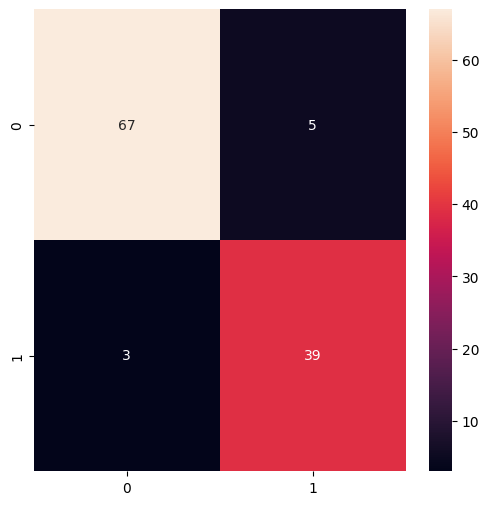

In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv_files = glob.glob('/content/breast_cancer/*.csv')
if csv_files:
    df = pd.read_csv(csv_files[0])
else:
    raise FileNotFoundError("No CSV file found in /content/breast_cancer/")

df

df.head()
df.info()
df.describe()
df.describe(include="O")
df.isna().sum().sort_values(ascending=True)
df.shape
df["Unnamed: 32"].unique
df.drop(columns = ["Unnamed: 32" , "id"] , inplace=True)
df


encoding_data = df[["diagnosis"]]
encoding_data
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
diagnosis_encoded = ohe.fit_transform(encoding_data)

department_encoded_df = pd.DataFrame(
    diagnosis_encoded,
    columns=ohe.get_feature_names_out(["diagnosis"])
)

department_encoded_df


df.columns
df.head()

# Keep only the 10 features used in Streamlit

selected_features = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean',
    'fractal_dimension_mean'
]

from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

df[selected_features] = robust_scaler.fit_transform(df[selected_features])

# Features and target
x = df[selected_features]
y = df['diagnosis']

# Encode target variable 'diagnosis' to numerical values (0 and 1)
y = y.map({'M': 1, 'B': 0})

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

reg = LogisticRegression()
reg.fit(x_train , y_train)

y_pred = reg.predict(x_test)
y_pred

reg.score(x_test, y_test)

print(classification_report(y_test,y_pred))

con = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(con,annot=True,fmt="d")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(x_train, y_train)

print(model.score(x_test, y_test))

0.9385964912280702


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    x,
    y,
    cv=20,
    scoring='accuracy'
)

print(scores.mean())

0.9442733990147782


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

for depth in [5, 10, 15, None]:
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=depth,
        random_state=42
    )

    score = cross_val_score(
        model,
        x,
        y,
        cv=20,
        scoring='accuracy'
    ).mean()

    print(depth, score)

5 0.9371921182266011
10 0.9442733990147782
15 0.9442733990147782
None 0.9442733990147782


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x, y)

print("Best Score:", grid.best_score_)
print("Best Params:", grid.best_params_)

Best Score: 0.950814536340852
Best Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

final_model.fit(x, y)

RandomForestClassifier(max_depth=10, random_state=42)

In [ ]:
import joblib

joblib.dump(final_model, "breast_cancer_model.pkl")
joblib.dump(robust_scaler, "breast_cancer_scaler.pkl")

['breast_cancer_scaler.pkl']

In [ ]:
!pip install catboost



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [ ]:
from xgboost import XGBClassifier

best_model = XGBClassifier(
    n_estimators=1160,
    max_depth=9,
    learning_rate=0.06988677858116417,
    subsample=0.8799818842797055,
    colsample_bytree=0.8917503279691137,
    gamma=0.6810333338398857,
    min_child_weight=2,
    random_state=42
)

best_model.fit(x, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8917503279691137, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.6810333338398857, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.06988677858116417,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1160, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import joblib

final_model = GradientBoostingClassifier(
    n_estimators=382,
    learning_rate=0.012930525445131411,
    max_depth=5,
    min_samples_split=18,
    min_samples_leaf=2,
    random_state=42
)

final_model.fit(x, y)

joblib.dump(final_model, "breast_cancer_model.pkl")

print("Model Saved Successfully")

In [ ]:
import joblib

joblib.dump(best_model, "breast_cancer_model.pkl")

['breast_cancer_model.pkl']

In [ ]:
robust_scaler = RobustScaler()
df[num_col] = robust_scaler.fit_transform(df[num_col])

In [ ]:
joblib.dump(robust_scaler, "breast_cancer_scaler.pkl")

['breast_cancer_scaler.pkl']

In [ ]:
import os

print(os.path.exists("breast_cancer_model.pkl"))
print(os.path.exists("breast_cancer_scaler.pkl"))

True
True
